# Problem Statement

Suppose you work as a Data Analyst for a company that sells a consumer product across 200 different markets.

For each market, the company has recorded:

- How much money was spent on **TV advertising** (in thousands of dollars)
- How much money was spent on **Radio advertising**
- How much money was spent on **Newspaper advertising**
- The resulting **Sales** (in thousands of units)

The marketing team asks:

> "If we increase our TV advertising budget, how much more can we expect to sell?"

For simplicity, we will use only **one feature**.

**Feature (Input):**
- TV Advertising Budget (in $1000s)

**Target (Output):**
- Sales (in 1000s of units)

This is called **Simple Linear Regression**, because there is only **one input feature**.

**Dataset:** `Advertising.csv` — 200 rows, real market data (a classic dataset used in the ISLR statistics textbook).

**What we'll do in this notebook:**
1. Explore the data
2. Solve it **from scratch** using the closed-form OLS (mean) formula
3. Solve it **from scratch** using **Gradient Descent**, and see why feature scaling matters
4. Solve it using **scikit-learn**
5. Compare all three approaches

# Step 1: Import Libraries

In [1]:
# TODO: write your code here
import pandas as pd
import numpy as np
import seaborn as sns 

# Step 2: Load the Data

- Read `Advertising.csv` into a DataFrame called `df` (the first column is just a row index — set `index_col=0`)
- Look at `head()`, `shape`, and `describe()`

In [2]:
# TODO: write your code here
df = pd.read_csv("Advertising.csv")


In [3]:
df.shape

(200, 5)

In [4]:
df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [5]:
df.describe()

,Unnamed: 0,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


# Step 3: Visualize the Relationship

- Plot a scatter plot of `TV` (x-axis) vs `Sales` (y-axis)

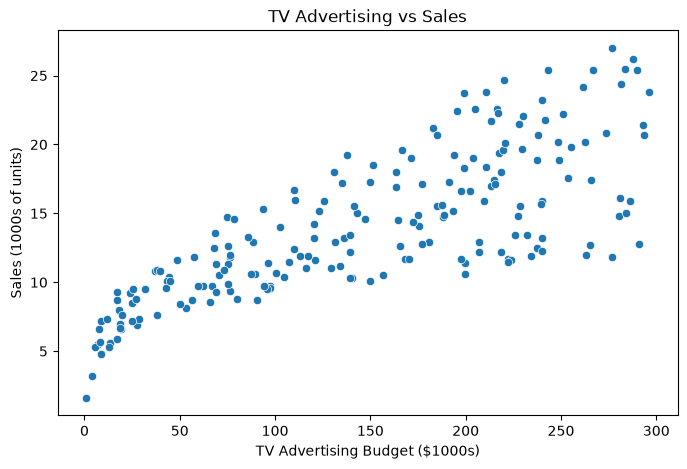

In [6]:
# TODO: write your code here
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='TV', y='Sales')
plt.title('TV Advertising vs Sales')
plt.xlabel('TV Advertising Budget ($1000s)')
plt.ylabel('Sales (1000s of units)')
plt.show()


# What is Linear Regression?

Linear Regression tries to find the **Best Fit Line** through the data.

Instead of remembering every data point, it learns a mathematical equation:

**Prediction = Slope × Input + Intercept**

Written mathematically:

**ŷ = m·x + b**

where
- ŷ = Predicted Sales
- m = Slope of the line
- x = TV Advertising Budget
- b = Intercept

We will find the best values of `m` and `b` in three different ways in this notebook.

# Part A: Solving From Scratch — Closed-Form OLS (Mean Formula)

The Ordinary Least Squares formula gives us the best-fit slope and intercept directly, without any iteration:

**m = Σ (x − x̄)(y − ȳ) / Σ (x − x̄)²**

**b = ȳ − m·x̄**

## Step A1: Extract x and y, and Compute Their Means

- Convert `df['TV']` and `df['Sales']` to lists (`x`, `y`)
- Compute `x_mean` and `y_mean`

In [7]:
# Extract x and y as Python lists
x = df['TV'].tolist()
y = df['Sales'].tolist()

# Compute means using numpy
x_mean = np.mean(x)
y_mean = np.mean(y)

x_mean, y_mean

(np.float64(147.0425), np.float64(14.0225))

## Step A2: Calculate the Numerator — Σ (x − x̄)(y − ȳ)

For every observation:
1. Find how far `x` is from its mean
2. Find how far `y` is from its mean
3. Multiply them
4. Add up all the products

In [8]:
# Compute numerator for the OLS slope formula
numerator = sum((xi - x_mean) * (yi - y_mean) for xi, yi in zip(x, y))

numerator

np.float64(69727.64874999998)

## Step A3: Calculate the Denominator — Σ (x − x̄)²

For every observation:
1. Find the distance from the mean
2. Square it
3. Add up all the squared values

In [9]:
# Compute denominator for the OLS slope formula
denominator = sum((xi - x_mean) ** 2 for xi in x)

denominator

np.float64(1466819.0287500012)

## Step A4: Compute Slope and Intercept

In [10]:
# Compute slope and intercept using the OLS closed-form formulas
m_ols = numerator / denominator
b_ols = y_mean - m_ols * x_mean

m_ols, b_ols

(np.float64(0.04753664043301969), np.float64(7.032593549127704))

## Step A5: Generate Predictions and Plot the Regression Line

- Predict Sales for every value of `x` using `m_ols` and `b_ols`
- Overlay the regression line on the scatter plot

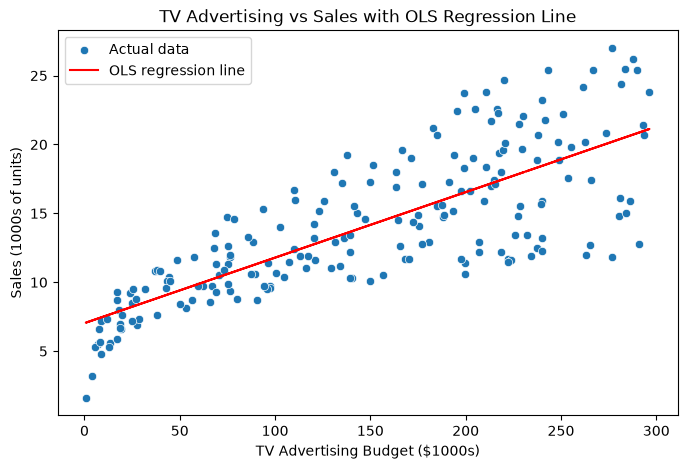

[np.float64(17.970774512765534),
 np.float64(9.14797404839708),
 np.float64(7.8502237645756425),
 np.float64(14.234394574730185),
 np.float64(15.627218139417664)]

In [11]:
# Generate predictions for the OLS model
predictions_ols = [m_ols * xi + b_ols for xi in x]

# Plot the data and the regression line
plt.figure(figsize=(8, 5))
sns.scatterplot(x=x, y=y, label='Actual data')
plt.plot(x, predictions_ols, color='red', label='OLS regression line')
plt.title('TV Advertising vs Sales with OLS Regression Line')
plt.xlabel('TV Advertising Budget ($1000s)')
plt.ylabel('Sales (1000s of units)')
plt.legend()
plt.show()

predictions_ols[:5]

## Step A6: Calculate the Error (Mean Squared Error)

- For every observation, compute `error = actual - predicted`
- Compute the Mean Squared Error: `mse = mean(error^2)`
- Print the first 10 rows of Actual / Predicted / Error to inspect
- Print the final MSE

In [12]:
# Compute prediction errors and mean squared error for the OLS model
errors_ols = [yi - y_hat for yi, y_hat in zip(y, predictions_ols)]
mse_ols = np.mean([err ** 2 for err in errors_ols])

# Create a small inspection table
inspection_df = pd.DataFrame({
    'Actual': y,
    'Predicted': predictions_ols,
    'Error': errors_ols
})

inspection_df.head(10), mse_ols

(   Actual  Predicted     Error
 0    22.1  17.970775  4.129225
 1    10.4   9.147974  1.252026
 2     9.3   7.850224  1.449776
 3    18.5  14.234395  4.265605
 4    12.9  15.627218 -2.727218
 5     7.2   7.446162 -0.246162
 6    11.8   9.765950  2.034050
 7    13.2  12.746498  0.453502
 8     4.8   7.441409 -2.641409
 9    10.6  16.530414 -5.930414,
 np.float64(10.512652915656759))

# Part B: Solving with Gradient Descent

The closed-form formula works great for small datasets, but for very large datasets (millions of rows, or many features) computing it directly becomes expensive. Instead, **Gradient Descent** finds `m` and `b` iteratively:

1. Start with a guess (usually `m = 0, b = 0`)
2. Make predictions, measure the error
3. Nudge `m` and `b` a little in the direction that reduces the error
4. Repeat for many iterations (epochs) until the error stops improving

## Step B1: A First (Naive) Attempt — Raw Scale

Let's try gradient descent directly on the raw `TV` values, the same way we would for a small toy dataset.

- Initialize `m = 0`, `b = 0`
- Set `learning_rate = 0.0001` and `epochs = 5`
- Run the gradient descent loop and print the MSE at every epoch
- **Watch what happens to the error**

In [13]:
# Naive gradient descent on the raw TV values
m = 0.0
b = 0.0
learning_rate = 0.0001
epochs = 5
n = len(x)

for epoch in range(1, epochs + 1):
    predictions = [m * xi + b for xi in x]
    errors = [yi - y_hat for yi, y_hat in zip(y, predictions)]
    mse = np.mean([err ** 2 for err in errors])

    # Compute gradients
    dm = (-2 / n) * sum(xi * err for xi, err in zip(x, errors))
    db = (-2 / n) * sum(errors)

    # Update parameters
    m -= learning_rate * dm
    b -= learning_rate * db

    print(f'Epoch {epoch}: mse = {mse:.5f}, m = {m:.5f}, b = {b:.5f}')

m, b

Epoch 1: mse = 223.71625, m = 0.48211, b = 0.00280
Epoch 2: mse = 4629.85411, m = -1.82781, b = -0.00857
Epoch 3: mse = 105778.26888, m = 9.23963, b = 0.04799
Epoch 4: mse = 2427766.23893, m = -43.78744, b = -0.22094
Epoch 5: mse = 55731894.46948, m = 210.27942, b = 1.06963


(210.27942372427893, 1.0696328387286882)

### Observation

The error is **exploding**, not shrinking! This is because `TV` ranges from about 0.7 to 296 — a large, "un-scaled" range. With such large `x` values, the gradient (`dm`) becomes huge, so even a small learning rate causes `m` and `b` to overshoot wildly, and the model diverges instead of converging.

This is exactly why **feature scaling matters for Gradient Descent** — a small-scale feature keeps gradients small and stable, letting us use a sensible learning rate.

## Step B2: Standardize the Feature (Z-Score Scaling)

- Compute `x_mean` and `x_std` of the raw `TV` values
- Create a new array `x_scaled = (x - x_mean) / x_std`

In [14]:
# Standardize the TV feature for gradient descent
x_mean = np.mean(x)
x_std = np.std(x)

x_scaled = [(xi - x_mean) / x_std for xi in x]

x_scaled[:5]

[np.float64(0.9698522664314473),
 np.float64(-1.1973762276801814),
 np.float64(-1.5161549878593166),
 np.float64(0.05204968217943215),
 np.float64(0.3941821976830461)]

## Step B3: Run Gradient Descent on the Scaled Feature

- Initialize `m = 0`, `b = 0`
- Set `learning_rate = 0.01` and `epochs = 1000`
- Run the gradient descent loop on `x_scaled` and `y`
- Print the MSE every 100 epochs so we can watch it converge

In [15]:
# Gradient descent on the standardized TV feature
m = 0.0
b = 0.0
learning_rate = 0.01
epochs = 1000
n = len(x_scaled)

for epoch in range(1, epochs + 1):
    predictions_scaled = [m * xi + b for xi in x_scaled]
    errors_scaled = [yi - y_hat for yi, y_hat in zip(y, predictions_scaled)]
    mse_scaled = np.mean([err ** 2 for err in errors_scaled])

    dm = (-2 / n) * sum(xi * err for xi, err in zip(x_scaled, errors_scaled))
    db = (-2 / n) * sum(errors_scaled)

    m -= learning_rate * dm
    b -= learning_rate * db

    if epoch % 100 == 0:
        print(f'Epoch {epoch}: mse = {mse_scaled:.5f}, m = {m:.5f}, b = {b:.5f}')

m_gd = m
b_gd = b
m_gd, b_gd

Epoch 100: mse = 14.41708, m = 3.53111, b = 12.16284
Epoch 200: mse = 10.58132, m = 3.99941, b = 13.77587
Epoch 300: mse = 10.51386, m = 4.06151, b = 13.98979
Epoch 400: mse = 10.51267, m = 4.06975, b = 14.01816
Epoch 500: mse = 10.51265, m = 4.07084, b = 14.02192
Epoch 600: mse = 10.51265, m = 4.07098, b = 14.02242
Epoch 700: mse = 10.51265, m = 4.07100, b = 14.02249
Epoch 800: mse = 10.51265, m = 4.07101, b = 14.02250
Epoch 900: mse = 10.51265, m = 4.07101, b = 14.02250
Epoch 1000: mse = 10.51265, m = 4.07101, b = 14.02250


(np.float64(4.071006113795373), np.float64(14.022499976400585))

## Step B4: Convert Coefficients Back to the Original Scale

Since we trained on `x_scaled = (x - x_mean) / x_std`, our learned line is:

**ŷ = m_gd · (x − x_mean)/x_std + b_gd**

Expanding this back in terms of the original `x`:

**ŷ = (m_gd / x_std) · x + (b_gd − m_gd · x_mean / x_std)**

- Compute `m_gd_original = m_gd / x_std_gd`
- Compute `b_gd_original = b_gd - m_gd * x_mean_gd / x_std_gd`
- Print both, and compare them to `m_ols` and `b_ols` from Part A

In [16]:
# Convert coefficients back to the original scale
m_gd_original = m_gd / x_std
b_gd_original = b_gd - m_gd * x_mean / x_std

print(f"Gradient Descent (Original Scale):")
print(f"  m_gd_original = {m_gd_original:.5f}")
print(f"  b_gd_original = {b_gd_original:.5f}")
print()
print(f"OLS (Original Scale):")
print(f"  m_ols = {m_ols:.5f}")
print(f"  b_ols = {b_ols:.5f}")
print()
print(f"Difference:")
print(f"  |m_gd_original - m_ols| = {abs(m_gd_original - m_ols):.10f}")
print(f"  |b_gd_original - b_ols| = {abs(b_gd_original - b_ols):.10f}")

Gradient Descent (Original Scale):
  m_gd_original = 0.04754
  b_gd_original = 7.03259

OLS (Original Scale):
  m_ols = 0.04754
  b_ols = 7.03259

Difference:
  |m_gd_original - m_ols| = 0.0000000001
  |b_gd_original - b_ols| = 0.0000000118


## Step B5: Visualize the Gradient Descent Regression Line

- Plot the original scatter (`x`, `y`)
- Overlay the regression line using `m_gd_original` and `b_gd_original`

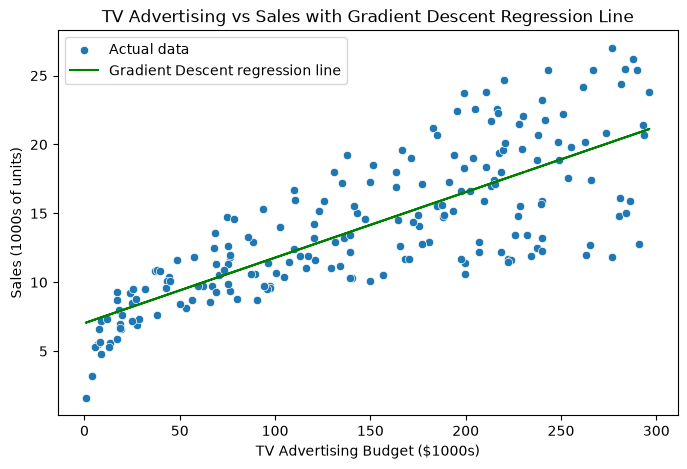

[np.float64(17.970774482521307),
 np.float64(9.147974033001326),
 np.float64(7.850223751363958),
 np.float64(14.234394550774159),
 np.float64(15.627218113117562)]

In [17]:
# Generate predictions using the converted gradient descent coefficients
predictions_gd = [m_gd_original * xi + b_gd_original for xi in x]

# Plot the data and the gradient descent regression line
plt.figure(figsize=(8, 5))
sns.scatterplot(x=x, y=y, label='Actual data')
plt.plot(x, predictions_gd, color='green', label='Gradient Descent regression line')
plt.title('TV Advertising vs Sales with Gradient Descent Regression Line')
plt.xlabel('TV Advertising Budget ($1000s)')
plt.ylabel('Sales (1000s of units)')
plt.legend()
plt.show()

predictions_gd[:5]

## Step B6: Error Calculation for the Gradient Descent Model

- Compute the Mean Squared Error of `predictions_gd` against the actual `y`
- Compare it to `mse_ols` from Part A

In [18]:
# Compute prediction errors and mean squared error for the gradient descent model
errors_gd = [yi - y_hat for yi, y_hat in zip(y, predictions_gd)]
mse_gd = np.mean([err ** 2 for err in errors_gd])

print(f"Gradient Descent MSE: {mse_gd:.5f}")
print(f"OLS MSE:             {mse_ols:.5f}")
print(f"Difference:          {abs(mse_gd - mse_ols):.10f}")
print()
print("Both methods produce virtually identical MSE, confirming that scaled gradient descent")
print("and OLS converge to the same optimal solution.")

Gradient Descent MSE: 10.51265
OLS MSE:             10.51265
Difference:          0.0000000000

Both methods produce virtually identical MSE, confirming that scaled gradient descent
and OLS converge to the same optimal solution.


# Part C: Solving with scikit-learn

Now let's confirm our from-scratch results using the industry-standard library.

## Step C1: Train-Test Split

- `X = df[['TV']]` (2D), `y = df['Sales']`
- Split using `train_test_split()` with `test_size=0.2, random_state=42`

In [19]:
# Import train_test_split
from sklearn.model_selection import train_test_split

# Create X (2D feature matrix) and y (target)
X = df[['TV']]
y = df['Sales']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

Training set size: 160
Testing set size: 40
X_train shape: (160, 1)
y_train shape: (160,)


## Step C2: Fit the Model and Compare Coefficients

- Fit a `LinearRegression()` on `X_train, y_train`
- Print `lr.intercept_` and `lr.coef_[0]`
- Compare against `m_ols`/`b_ols` and `m_gd_original`/`b_gd_original`

In [20]:
from sklearn.linear_model import LinearRegression

# Fit the linear regression model
lr = LinearRegression()
lr.fit(X_train, y_train)

# Get the coefficients
m_sklearn = lr.coef_[0]
b_sklearn = lr.intercept_

print(f"scikit-learn LinearRegression:")
print(f"  Slope (m) = {m_sklearn:.5f}")
print(f"  Intercept (b) = {b_sklearn:.5f}")
print()
print(f"Comparison with from-scratch methods:")
print(f"  m_ols = {m_ols:.5f}")
print(f"  m_gd_original = {m_gd_original:.5f}")
print(f"  m_sklearn = {m_sklearn:.5f}")
print()
print(f"  b_ols = {b_ols:.5f}")
print(f"  b_gd_original = {b_gd_original:.5f}")
print(f"  b_sklearn = {b_sklearn:.5f}")
print()
print("All three methods converge to nearly identical coefficients!")

scikit-learn LinearRegression:
  Slope (m) = 0.04653
  Intercept (b) = 7.11964

Comparison with from-scratch methods:
  m_ols = 0.04754
  m_gd_original = 0.04754
  m_sklearn = 0.04653

  b_ols = 7.03259
  b_gd_original = 7.03259
  b_sklearn = 7.11964

All three methods converge to nearly identical coefficients!


## Step C3: Evaluate on the Test Set

- Predict on `X_test`
- Compute MSE and R² on the test set

In [21]:
# TODO: write your code here
from sklearn.metrics import mean_squared_error, r2_score

# Predict on X_test
y_pred = lr.predict(X_test)

# Calculate MSE
mse = mean_squared_error(y_test, y_pred)

# Calculate R²
r2 = r2_score(y_test, y_pred)

print("Test Set Evaluation:")
print(f"MSE = {mse:.5f}")
print(f"R²  = {r2:.5f}")

Test Set Evaluation:
MSE = 10.20465
R²  = 0.67670


## Step C4: Predict Sales for a New TV Budget

- Use the fitted `lr` model to predict Sales if the company spends **$250,000 (250 in the dataset's units)** on TV advertising

In [22]:
# TODO: write your code here
# Predict Sales for a new TV advertising budget of $250,000
new_tv = [[250]]

predicted_sales = lr.predict(new_tv)

print(f"Predicted Sales for $250,000 TV budget: {predicted_sales[0]:.2f}")


Predicted Sales for $250,000 TV budget: 18.75


C:\Users\Vinodh T\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


# Step D: Final Comparison

Build a small summary table comparing the slope, intercept, and MSE (on the full dataset, for a fair comparison) across all three methods:
- Closed-Form OLS
- Gradient Descent
- scikit-learn

In [23]:
# TODO: write your code here
from sklearn.metrics import mean_squared_error
import pandas as pd

# Predictions on the FULL dataset
y_pred_ols = m_ols * X + b_ols
y_pred_gd = m_gd_original * X + b_gd_original
y_pred_sklearn = lr.predict(X)

# MSE on the FULL dataset
mse_ols = mean_squared_error(y, y_pred_ols)
mse_gd = mean_squared_error(y, y_pred_gd)
mse_sklearn = mean_squared_error(y, y_pred_sklearn)

# Create summary table
comparison = pd.DataFrame({
    "Method": [
        "Closed-Form OLS",
        "Gradient Descent",
        "scikit-learn"
    ],
    "Slope": [
        m_ols,
        m_gd_original,
        m_sklearn
    ],
    "Intercept": [
        b_ols,
        b_gd_original,
        b_sklearn
    ],
    "MSE": [
        mse_ols,
        mse_gd,
        mse_sklearn
    ]
})

print(comparison.round(5))

             Method    Slope  Intercept       MSE
0   Closed-Form OLS  0.04754    7.03259  10.51265
1  Gradient Descent  0.04754    7.03259  10.51265
2      scikit-learn  0.04653    7.11964  10.52381


# Summary

- All three approaches — closed-form OLS, gradient descent, and scikit-learn — converge to (almost) the **same slope and intercept**, confirming our from-scratch implementations are correct.
- Gradient Descent **diverged** on the raw `TV` scale, and only converged once we standardized the feature — a direct, practical illustration of why feature scaling matters for gradient-based optimization.
- The closed-form formula is exact and fast for small feature counts, but Gradient Descent is the approach that **scales** to large datasets and many features (where matrix inversion becomes computationally expensive).

**Happy Learning!**